In [117]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [133]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from simulators import ContextManager, NestedModelFamily
from simulators.benchmarks import CollapsingBoundDDM

In [119]:
param_names = ["v","a","zr","tau","s_v","decay","s_tau","sigma"]

In [120]:
context_manager = ContextManager(
    parameter_names=param_names,
    fixed_parameters={"zr", "tau", "sigma"}
)
context_manager.param_dims = {k: 1 for k in param_names}
context_manager.param_index_slices, context_manager.param_vector_size = context_manager._build_parameter_slices()

In [121]:
family = NestedModelFamily(
    name="collapsing_bound",
    model=CollapsingBoundDDM,
    context_manager=context_manager,
    num_samples=50
)

In [125]:
# Provide only the fixeds, let v,a come from sampler
out = family.sample(num_samples=1000, params={"zr":0.5,"tau":0.3,"sigma":1.0})

In [126]:
params_used = out["full_params"]
print("Simulation data keys:", out["sim_data"].keys())
print("Shape of v param passed:", out["sim_data"]["rts"].shape)

Simulation data keys: dict_keys(['rts', 'choices'])
Shape of v param passed: (1000,)


<Axes: ylabel='Count'>

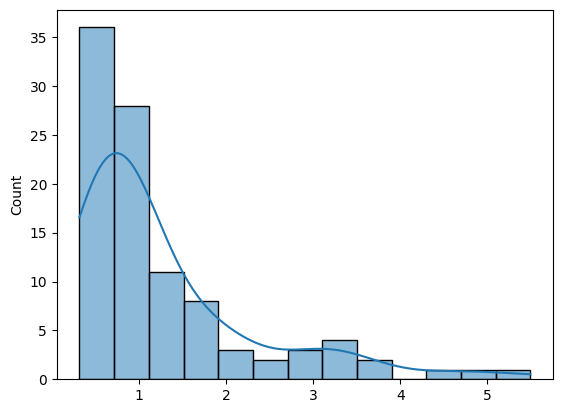

In [127]:
sns.histplot(rts, kde=True)

In [128]:
print("variant:", out["variant_name"])
print("trials:", rts.size, "non-terminations:", int((rts == -1.0).sum()))
valid = rts[rts > 0]
print("rt p10/50/90:", np.percentile(valid, [10, 50, 90]))
print("choice rate (valid):", np.mean(choices[rts > 0]))
print("full_params shape:", out["full_params"].shape)

variant: collapsing_bound
trials: 100 non-terminations: 0
rt p10/50/90: [0.45323486 0.88012254 2.943256  ]
choice rate (valid): 0.92
full_params shape: (8,)


### Testing multiple configs

In [131]:
configs = [
    {"zr": 0.50, "tau": 0.30, "sigma": 1.0},                # baseline fixeds only
    {"zr": 0.55, "tau": 0.25, "sigma": 1.0, "a": 1.2},      # also fix 'a'
    {"zr": 0.45, "tau": 0.35, "sigma": 1.0, "s_v": 0.15},   # also fix 's_v'
    {"zr": 0.50, "tau": 0.30, "sigma": 1.0, "decay": 0.02}, # also fix 'decay'
    {"zr": 0.50, "tau": 0.30, "decay": 0.02},               # also fix 'decay'
]

In [134]:
results = []
for cfg in configs:
    out = family.sample(num_samples=1000, params=cfg)
    rts = out["sim_data"]["rts"]
    valid_rts = rts[rts > 0]   # exclude non-terminations
    results.append(valid_rts)

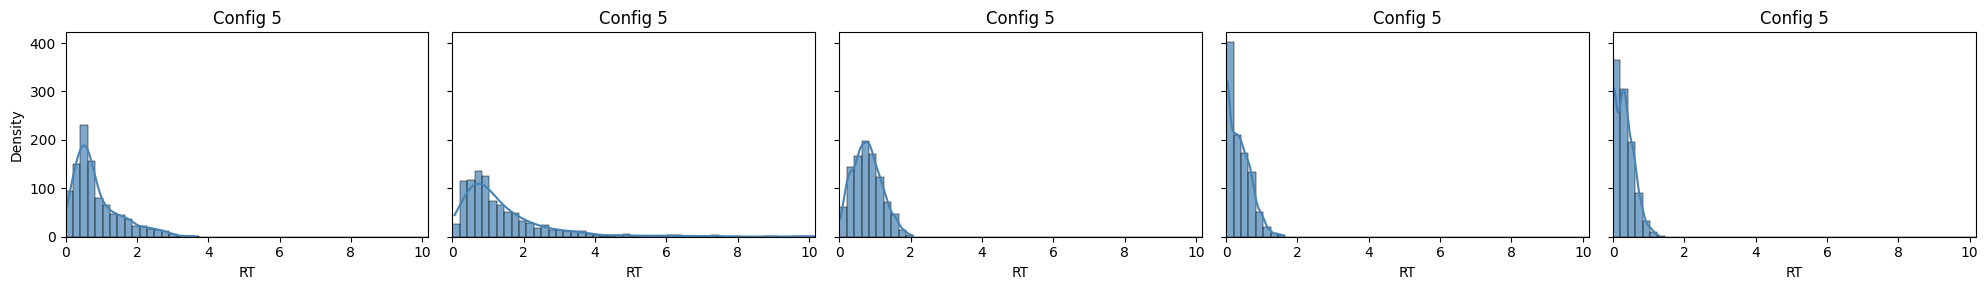

In [141]:
n_cfg = len(configs)
fig, axes = plt.subplots(1, n_cfg, figsize=(4*n_cfg, 3), sharey=True)

bins = np.linspace(0, max(np.max(r) for r in results), 50)

for i, ax in enumerate(axes.ravel()):
    rts = results[i]
    sns.histplot(rts, bins=bins, kde=True, alpha=0.7, color="steelblue", ax=ax)
    ax.set_title(f"Config {configs.index(cfg)+1}")
    ax.set_xlabel("RT")
    ax.set_xlim(0, bins[-1])

axes[0].set_ylabel("Density")
plt.tight_layout()